# Pothole & Road Surface Damage — Kaggle Pipeline

Mirrors `scripts/` end to end on Kaggle's GPU runtime, where the RDD2022 data and CUDA actually live.
Local (Apple Silicon / MPS) is for iterating on script logic only — real training runs happen here.

Importing just this notebook via Kaggle's GitHub integration does NOT bring along `scripts/` —
Kaggle only pulls the single `.ipynb`. The next cell clones the repo instead. Attach the RDD2022
dataset as an Input separately.

In [1]:
import os

REPO_DIR = "/kaggle/working/pothole_cv"
if not os.path.exists(REPO_DIR):
    !git clone --depth 1 https://github.com/kabirarshafidz/pothole_cv.git {REPO_DIR}

%pip install -q -r {REPO_DIR}/requirements-kaggle.txt

Cloning into '/kaggle/working/pothole_cv'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 17 (delta 0), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 13.61 KiB | 696.00 KiB/s, done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1

In [2]:
import sys

sys.path.append(f"{REPO_DIR}/scripts")

import torch

from utils import CLASS_NAMES, COUNTRIES, DATA_ROOT, OUTPUTS_ROOT, RUNS_ROOT, get_device

print("device:", get_device())
print("cuda available:", torch.cuda.is_available())
print("DATA_ROOT:", DATA_ROOT)

device: cuda
cuda available: True
DATA_ROOT: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT


## 1. Data prep

RDD_SPLIT is already YOLO-formatted (`.txt` labels) and already split 70/15/15, with all 6
countries mixed together in each of train/val/test. Filenames carry a country prefix
(`Japan_000123.jpg`) — `build_country_lists` filters by that prefix into per-country image
list files under `outputs/splits/`, which is how we get a Japan-only training set and
per-country test sets for the generalization study. No XML conversion or re-splitting needed
here (and re-splitting would just reshuffle a split someone else already froze).

In [3]:
from build_country_lists import build_lists

build_lists()

# Sanity-check the pre-converted label class order matches CLASS_NAMES (D00, D10, D20, D44, D40).
# This Kaggle copy has 5 classes, not the 4 in the RDD2022 paper — class id 4 is Pothole (D40).
# If class ids in these files don't look like 0-4, or D40 (pothole) AP comes back near zero
# later, the upstream conversion used a different order than we assume.
sample_label = next((DATA_ROOT / "train" / "labels").glob("Japan_*.txt"))
print(sample_label.name)
print(sample_label.read_text())

Japan train: 7432 images -> /kaggle/working/outputs/splits/Japan_train.txt
India train: 5368 images -> /kaggle/working/outputs/splits/India_train.txt
Czech train: 1962 images -> /kaggle/working/outputs/splits/Czech_train.txt
Norway train: 5708 images -> /kaggle/working/outputs/splits/Norway_train.txt
United_States train: 3348 images -> /kaggle/working/outputs/splits/United_States_train.txt
China train: 3051 images -> /kaggle/working/outputs/splits/China_train.txt
Japan val: 1550 images -> /kaggle/working/outputs/splits/Japan_val.txt
India val: 1172 images -> /kaggle/working/outputs/splits/India_val.txt
Czech val: 431 images -> /kaggle/working/outputs/splits/Czech_val.txt
Norway val: 1256 images -> /kaggle/working/outputs/splits/Norway_val.txt
United_States val: 704 images -> /kaggle/working/outputs/splits/United_States_val.txt
China val: 645 images -> /kaggle/working/outputs/splits/China_val.txt
Japan test: 1524 images -> /kaggle/working/outputs/splits/Japan_test.txt
India test: 1166 i

In [4]:
DRY_RUN = False        # True -> tiny subset, 1 epoch, to smoke-test the pipeline fast
FORCE_RETRAIN = False  # True -> retrain even if best.pt already exists on disk

from train import make_dataset_yaml

dataset_yaml_path = make_dataset_yaml("Japan", limit=40 if DRY_RUN else None)
print(dataset_yaml_path) 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
/kaggle/working/outputs/splits/Japan.yaml


## 2. Train (YOLOv8s, Japan baseline)

Expected mAP@50: 0.60–0.67. Above 0.80 almost certainly means train/test overlap — recheck the split.

In [5]:
from ultralytics import YOLO

best_weights = RUNS_ROOT / "japan_baseline" / "weights" / "best.pt"

if best_weights.exists() and not FORCE_RETRAIN:
    print(f"Reusing existing weights at {best_weights} (set FORCE_RETRAIN=True to retrain)")
else:
    model = YOLO("yolov8s.pt")
    model.train(
        data=dataset_yaml_path,
        imgsz=640,
        batch=16,
        epochs=1 if DRY_RUN else 50,
        patience=10,
        device=get_device(),
        project=str(RUNS_ROOT),
        name="japan_baseline",
    )

New https://pypi.org/project/ultralytics/8.4.92 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/outputs/splits/Japan.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosai

## 3. Cross-country generalization

Evaluate the Japan-trained model on all 6 countries. Expect a 15–25 mAP point drop
Japan → India, with D20 (alligator crack) transferring worst — that's the core finding, not a bug.

In [6]:
import csv

from evaluate import make_test_yaml

eval_model = YOLO(str(best_weights))
OUTPUTS_ROOT.mkdir(parents=True, exist_ok=True)
results_path = OUTPUTS_ROOT / "generalization_results.csv"

with open(results_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["country", "map50", "map50_95", "precision", "recall"])
    for country in COUNTRIES:
        data_yaml = make_test_yaml(country, limit=20 if DRY_RUN else None)
        metrics = eval_model.val(data=data_yaml, device=get_device())
        writer.writerow([country, metrics.box.map50, metrics.box.map, metrics.box.mp, metrics.box.mr])

print(f"Wrote {results_path}")

Ultralytics 8.4.91 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 2.1±2.3 ms, read: 13.1±5.8 MB/s, size: 65.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test/labels... 1524 images, 123 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1524/1524 240.0it/s 6.4s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 4.2it/s 23.0s
                   all       1524       3617      0.604      0.597      0.594      0.297
                   D00        423        624      0.571      0.465      0.486      0.2

## 4. Severity scoring (area vs depth)

Compares the area-based baseline against Depth Anything-assisted severity on a sample test image.

In [7]:
from severity import area_severity, depth_severity
from PIL import Image
from transformers import pipeline
import numpy as np

sample_image_path = next((DATA_ROOT / "test" / "images").glob("Japan_*.jpg"))
sample_image = Image.open(sample_image_path).convert("RGB")
detections = eval_model.predict(sample_image, device=get_device())[0]

depth_pipe = pipeline("depth-estimation", model="LiheYoung/depth-anything-small-hf", device=get_device())
depth_map = np.array(depth_pipe(sample_image)["depth"])

for box in detections.boxes:
    xyxy = box.xyxy[0].tolist()
    a = area_severity(xyxy, sample_image.size[::-1])
    d = depth_severity(xyxy, depth_map)
    print(f"class={int(box.cls[0])} area_severity={a:.4f} depth_severity={d:.4f}")


0: 640x640 2 D10s, 16.1ms
Speed: 3.7ms preprocess, 16.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


config.json:   0%|          | 0.00/954 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


class=1 area_severity=0.0181 depth_severity=104.5447
class=1 area_severity=0.0463 depth_severity=154.9713


## 5. Demo visualization

Annotated image with severity-colored boxes (green=low, orange=medium, red=high).

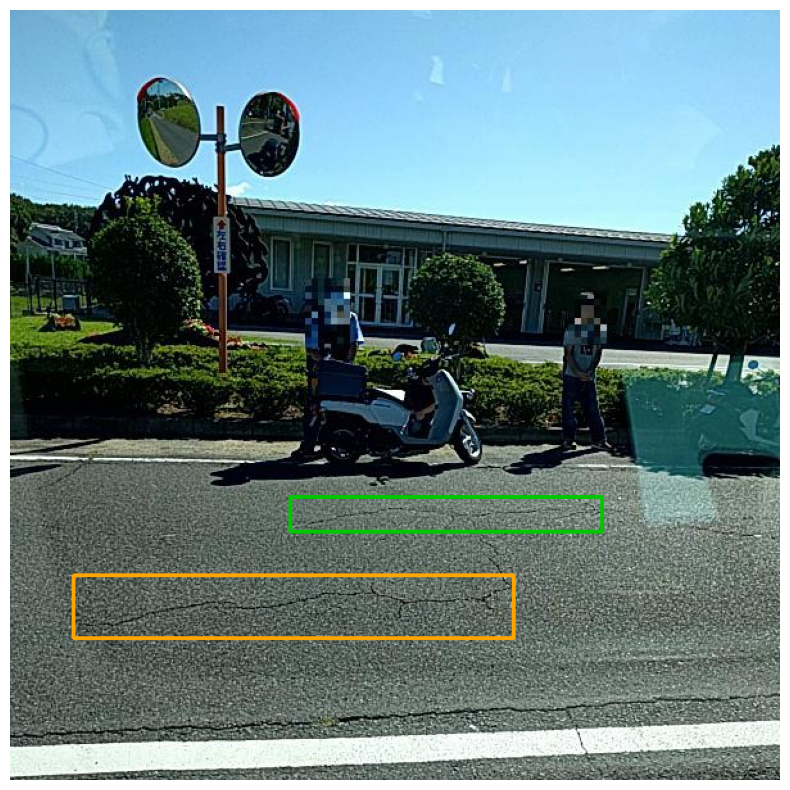

In [8]:
import cv2
import matplotlib.pyplot as plt

from visualize import SEVERITY_COLORS, bucket

image_bgr = cv2.imread(str(sample_image_path))
for box in detections.boxes:
    x1, y1, x2, y2 = (int(v) for v in box.xyxy[0].tolist())
    score = area_severity((x1, y1, x2, y2), image_bgr.shape[:2])
    color = SEVERITY_COLORS[bucket(score)]
    cv2.rectangle(image_bgr, (x1, y1), (x2, y2), color, 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()